> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 14: API Integration

## Outline
1. Import customer reviews
2. Create prompts for LLM
3. Summarize Customer Reviews

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Customer Reviews - Business Context

This dataset represents customer reviews of Megatelco phones, which provides valuable insight into customer satisfaction, product performance, and brand perception. In a business context, companies use this type of data to understand how customers feel about their products, identify common issues (like battery life or software bugs), and detect what features customers value most (such as camera quality or speed). Because reviews are unstructured text, they contain rich, detailed feedback that goes beyond simple ratings—making them especially useful for improving products, guiding marketing strategies, and reducing customer churn.

In this lab, instead of using traditional text analysis methods, you will use a large language model (LLM) to analyze the reviews. Traditional text analytics techniques (like keyword counting or basic sentiment tools such as VADER) rely on predefined rules or dictionaries and often struggle with nuance, sarcasm, or context. LLMs, on the other hand, are trained on massive amounts of text and can understand language more like a human—recognizing tone, context, and subtle meaning. This allows them to perform more advanced tasks, such as summarizing feedback, detecting themes, interpreting sarcasm, and generating insights directly from raw text. Using an LLM enables businesses to extract deeper, more accurate insights from customer reviews at scale, making it a powerful tool for modern data analysis.

## Data Dictionary

| Column                        | Data Type       | Description                                                  |
|------------------------------|------------------|--------------------------------------------------------------|
| `Date`                   | Date           | Date of the review                                              |
| `Stars`                 | Integer           | Number of stars, from 1 (low) to 5 (high)                                     |
| `Review`             | String       | Text of the customer review                      |


## APIs for AI

An API for a large language model (LLM) allows applications to send text (like a question or prompt) to a powerful AI model hosted on a server and receive a generated response in return. Instead of building and running their own AI models, businesses can simply make requests to the API—often with just a few lines of code—and get capabilities like text generation, summarization, classification, or customer support automation.

This is useful for businesses because it makes advanced AI accessible without requiring deep technical expertise or expensive infrastructure. Companies can quickly integrate LLMs into their products and workflows to improve efficiency, enhance customer experiences (like chatbots or personalized responses), and gain insights from large amounts of text data, all while saving time and development costs.




## Part 1: Load the Data

### What you are going to do:
- Load the dataset
- Preview the data

**Things to notice:**
- Do you see any elements in the reviews that would difficult for VADER or other lexicon-based models to process?


In [43]:
import pandas as pd
import google.generativeai as genai

Create a dataframe containing sample reviews for use in the lab

In [44]:
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/megatelco_customer_reviews.csv"
df = pd.read_csv(url)

df.head()

,Date,Stars,Review
0,2025-12-01,4,"I purchased a Megatelco phone last week, and i..."
1,2025-12-03,3,"My Megatelco phone arrived fast, but I've noti..."
2,2025-12-05,5,Megatelco offers top-notch phones! I'm happy w...
3,2025-12-08,4,I've been using Megatelco phones for a while n...
4,2025-12-10,2,"Regrettably, my experience with Megatelco was ..."


# Part 2 : Prepare the LLM Prompt
### What you are going to do:
- Instruct the LLM on the context and desired output

### Why this matters:
A LLM needs to know what you are trying to accomplish, what data you will provide, what it should do with the data, and how to format the output.  Your prompt needs to set all of this context before passing in a review.  

In [45]:
base_prompt = (
    "Summarize the sentiment and most important points in the following user review for "
    "a phone company named Megatelco.  You will evaluate the sentiment, theme (in 2 words or less), count the number of words, and suggest an action (in 2 words or less)."
     "Format the output in a table with columns: "
     "Sentiment, Theme, Word Count, Suggested Action. Review: "
)

#Get the first review and pair it with the prompt
review = df['Review'].values[0]
prompt = base_prompt + review
print(prompt)

Summarize the sentiment and most important points in the following user review for a phone company named Megatelco.  You will evaluate the sentiment, theme (in 2 words or less), count the number of words, and suggest an action (in 2 words or less).Format the output in a table with columns: Sentiment, Theme, Word Count, Suggested Action. Review: I purchased a Megatelco phone last week, and it has sick performance. The camera quality is great, and the battery life is long. Overall, a solid 4-star experience.


### 🔧 Try It Yourself — Part 2

1. Create a new version of the prompt that adds two additional columns to the output.   (this columns should be numeric values you can visualize at a later time)

### In Your Response:
1. Why did you pick the two columns that you added?  What business insight would they provide?

In [46]:
# 🔧 Enter your code here

### ✍️ Your Response: 🔧
1.

# Part 3: Connect with the API and Test

### What you are going to do:
- Create a connection to Gemini
- Run a test prompt
- Pass the full collection of reviews to the API (either in a batch or one-by-one in a loop)
- Format the output in a dataframe.   

### Do the following
- Go to https://aistudio.google.com/api-keys
- Click on the `Get API key` link on the bottom left corner
- Copy the value into the box below
- Send the first customer review to Gemini for analysis, then view the result

**Things to notice:**
- Is there any limit to the number of free requests you can make to Gemini?  (without payment)

### 🔧 Action Required: Get and Store your API Key

1. Go to [Google AI Studio](https://aistudio.google.com/api-keys).
2. Click on the `Get API key` link on the bottom left corner.
3. **In Google Colab**, click on the "🔑" icon (Secrets) in the left sidebar.
4. Add a new secret with the name `GOOGLE_API_KEY` and paste your API key as the value.
5. Enable "Notebook access" for this secret.

After setting up the API key in Colab secrets and running the cell above, you should now be able to run the next cell to test the API connection.

In [47]:
from google.colab import userdata

# Configure the API key
API_KEY = userdata.get('GOOGLE_API_KEY') # Fetches the API key from Colab secrets
genai.configure(api_key=API_KEY)
model = genai.GenerativeModel('models/gemini-2.5-flash')
print("Gemini API configured successfully.")

Gemini API configured successfully.


In [48]:
response = model.generate_content(prompt)
print(response.candidates[0].content.parts[0].text)

| Sentiment | Theme          | Word Count | Suggested Action |
|:----------|:---------------|:-----------|:-----------------|
| Positive  | Good Performance | 28         | Thank User       |


### 🔧 Try It Yourself — Part 3
Ask Gemini to help you loop through the reviews, one by one, and format them into a dataframe. Use the following steps:
1. Build a full prompt by combining the base prompt that you created above with one or more reviews
2. Pass the full prompt to Gemini
3. Format the response into a dataframe
4. If you are processing one row at a time, pass the next prompt (in a loop) until you have processed all of the reviews
5. Show the final dataframe using `df.head()`

### In Your Response:
1. How does the output of the LLM compare to the output we saw in week 13 from VADER or TextBlob?

In [49]:
import pandas as pd
import time

# Assuming new_base_prompt is defined from previous steps
# If not, please define it as per 'Try It Yourself - Part 2'
new_base_prompt = (
    "Summarize the sentiment and most important points in the following user review for "
    "a phone company named Megatelco.  You will evaluate the sentiment, theme (in 2 words or less), "
    "count the number of words, extract the star rating (1-5), count the number of characters, "
    "and suggest an action (in 2 words or less). Format the output in a table with columns: "
    "Sentiment, Theme, Word Count, Suggested Action, Stars, Character Count. Review: "
)

results = []

start_time = time.time()

for index, row in df.iterrows():
    review_text = row['Review']
    full_prompt = new_base_prompt + review_text

    try:
        response = model.generate_content(full_prompt)
        # Extracting the text content from the response
        if response.candidates and response.candidates[0].content.parts:
            response_text = response.candidates[0].content.parts[0].text

            # Parsing the markdown table output
            lines = response_text.strip().split('\n')

            if len(lines) >= 2: # Ensure there's a header and at least one data row
                # The first line is header, second is separator, third is data
                header_line = lines[0].strip()
                data_line = lines[2].strip() # Assuming single data row per response

                # Remove leading/trailing pipes and split by pipe
                columns = [col.strip() for col in header_line.strip('|').split('|')]
                values = [val.strip() for val in data_line.strip('|').split('|')]

                # Create a dictionary for this review's result
                # Ensure column and value lists have the same length
                if len(columns) == len(values):
                    result_dict = dict(zip(columns, values))
                    results.append(result_dict)
                else:
                    print(f"Warning: Mismatch in column/value count for review {index}. Skipping.")
                    print(f"Columns: {columns}")
                    print(f"Values: {values}")
            else:
                print(f"Warning: Unexpected response format for review {index}. Skipping.")
                print(response_text)
        else:
            print(f"Warning: No content in response for review {index}. Skipping.")

    except Exception as e:
        print(f"Error processing review {index}: {e}")

end_time = time.time()
elapsed_time = end_time - start_time

# Create a DataFrame from the collected results
llm_results_df = pd.DataFrame(results)

# Convert 'Word Count', 'Stars', 'Character Count' to numeric types if they exist
for col in ['Word Count', 'Stars', 'Character Count']:
    if col in llm_results_df.columns:
        llm_results_df[col] = pd.to_numeric(llm_results_df[col], errors='coerce')


print(f"Total elapsed time for {len(df)} reviews: {elapsed_time:.2f} seconds")
display(llm_results_df.head())


Total elapsed time for 5 reviews: 29.53 seconds


,Sentiment,Theme,Word Count,Suggested Action,Stars,Character Count
0,Positive,Good performance,37,Maintain quality,4,187
1,Mixed,Software Lag,34,Improve Software,3,211
2,Positive,Phone quality,29,Thank customer,5,188
3,Positive,Product satisfaction,34,Maintain quality,4,224
4,Negative,Connectivity Issues,30,Investigate Issues,2,185


### ✍️ Your Response: 🔧
1. Compare to VADER and TextBlob, LLM show the strength of providing structured data analysis result like text length and star ranking,




# Part 4: Visualize the Output
### What you are going to do:
- create visualizations to summarize the customer reviews.

## Why this matters:
If we have thousands of reviews, you will need to summarize them for management use.  Each chart should tell a distinct story about the customer feedback, themes and suggested action items.  

### 🔧 Try It Yourself — Part 4
Create at least four visualizations to answer the following questions:
1. What are the main themes?
2. For each theme, what is the sentiment associated with the theme?
3. What are the action items that should be taken to reduce churn?
4. Add one or more visualizations that will show the insights from the fields that you added in part 2.  

### In Your Response:
1. Why did you pick the charts or image types for each of the four visualizations?  

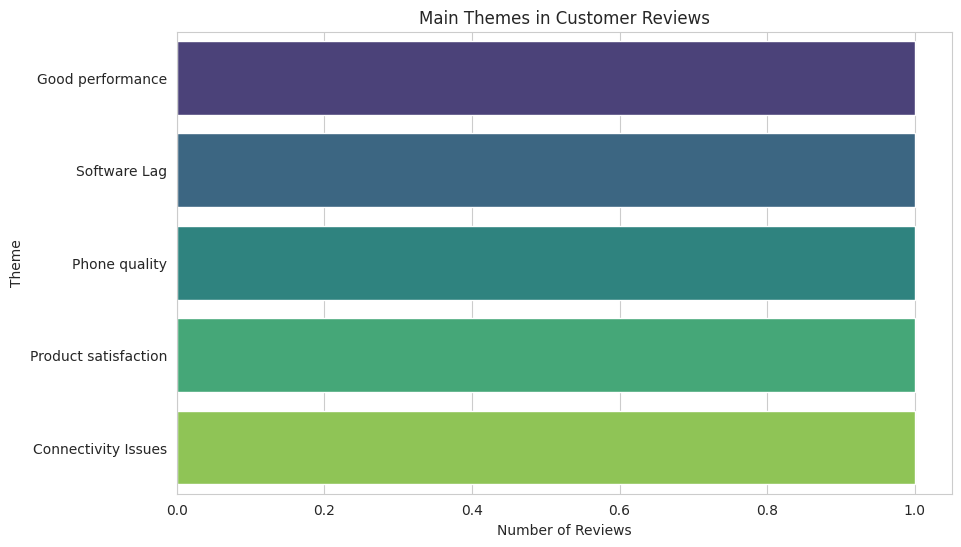

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# 1. What are the main themes?
plt.figure(figsize=(10, 6))
sns.countplot(y='Theme', data=llm_results_df, order=llm_results_df['Theme'].value_counts().index, hue='Theme', palette='viridis', legend=False)
plt.title('Main Themes in Customer Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Theme')
plt.show()

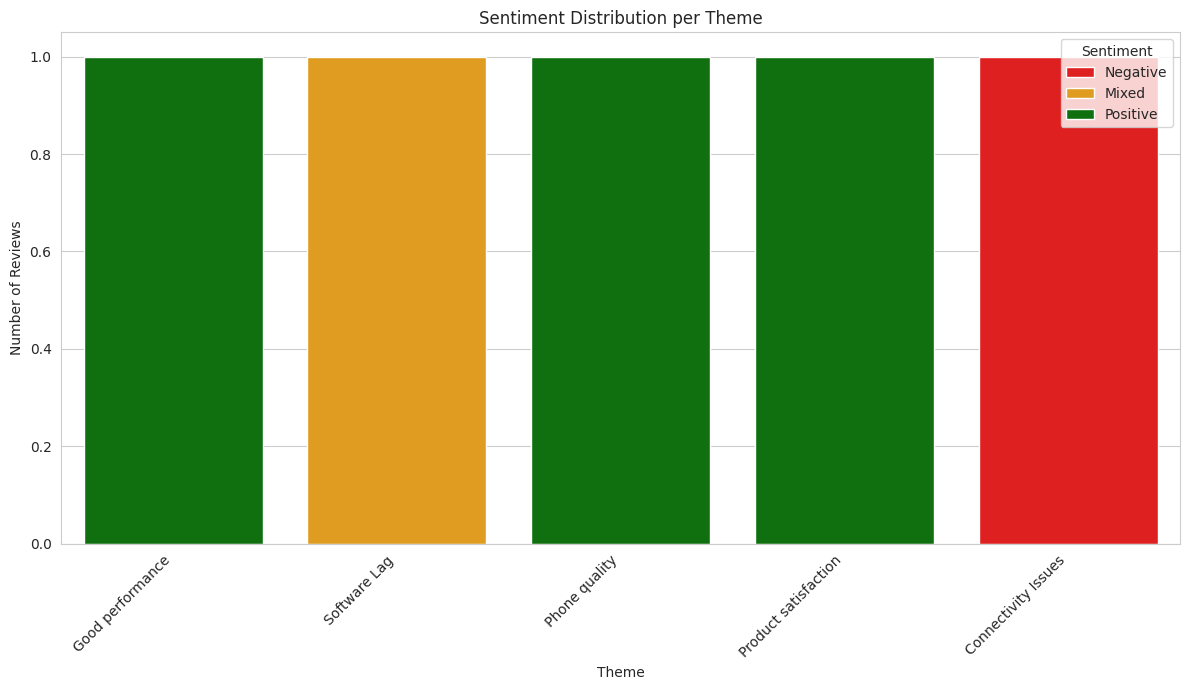

In [51]:
# 2. For each theme, what is the sentiment associated with the theme?

# Ensure 'Sentiment' is a categorical type with a defined order for consistent plotting
sentiment_order = ['Negative', 'Mixed', 'Positive']
llm_results_df['Sentiment'] = pd.Categorical(llm_results_df['Sentiment'], categories=sentiment_order, ordered=True)

plt.figure(figsize=(12, 7))
sns.countplot(data=llm_results_df, x='Theme', hue='Sentiment', palette={'Positive': 'green', 'Mixed': 'orange', 'Negative': 'red'})
plt.title('Sentiment Distribution per Theme')
plt.xlabel('Theme')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

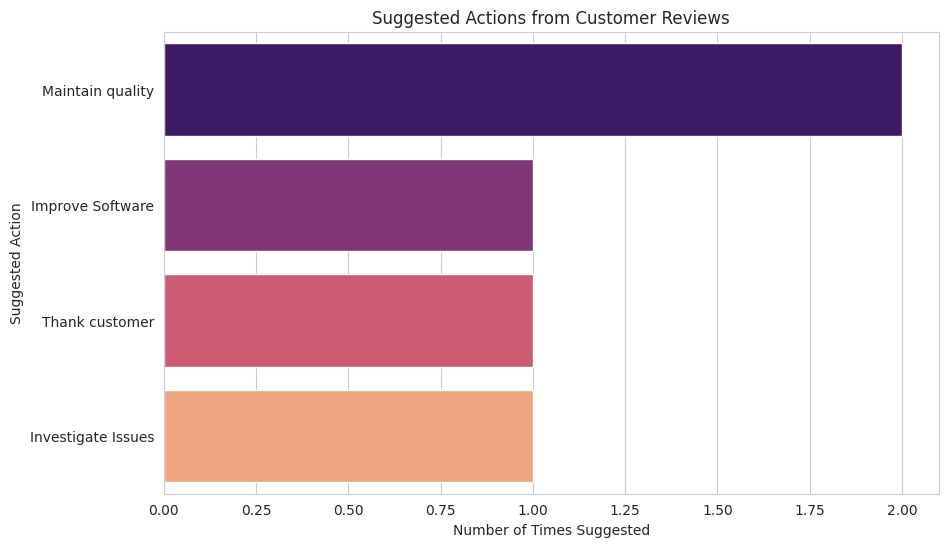

In [52]:
# 3. What are the action items that should be taken to reduce churn?
plt.figure(figsize=(10, 6))
sns.countplot(y='Suggested Action', data=llm_results_df, order=llm_results_df['Suggested Action'].value_counts().index, hue='Suggested Action', palette='magma', legend=False)
plt.title('Suggested Actions from Customer Reviews')
plt.xlabel('Number of Times Suggested')
plt.ylabel('Suggested Action')
plt.show()

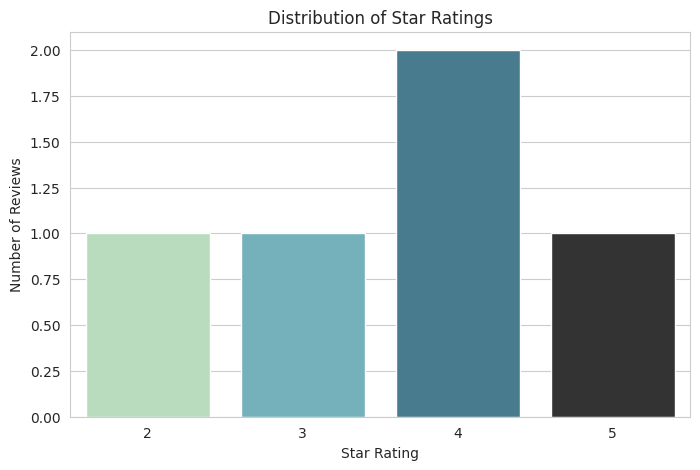

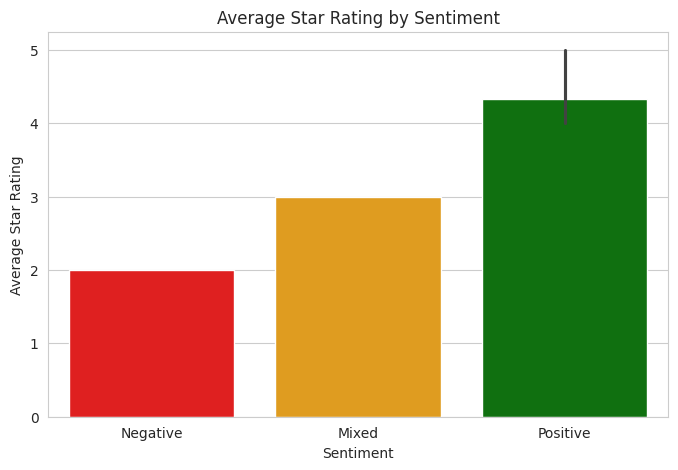

In [53]:
# 4. Insights from the fields added in Part 2 (Stars and Character Count)

# 4a. Distribution of Star Ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='Stars', data=llm_results_df, hue='Stars', palette='GnBu_d', legend=False)
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.show()

# 4b. Average Star Rating by Sentiment
plt.figure(figsize=(8, 5))
sns.barplot(x='Sentiment', y='Stars', data=llm_results_df, hue='Sentiment', palette={'Positive': 'green', 'Mixed': 'orange', 'Negative': 'red'}, legend=False)
plt.title('Average Star Rating by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Star Rating')
plt.show()

### ✍️ Your Response: 🔧
1. I chose the countplot for comparing frequency how many topics were there.
2. To divide the data details whether customer reflections are 'positive','negative', or 'mixed', I used countplot with hue ro doing that.
3. To find the frequency of 'suggested action', I used countplot, which is useful for visualizing comparing.
4a. For finding satisfaction distribution,I used countplot again.
4b. Since I want to compare average satisfaction of sentiments, I used barplot, and It showed the score of 'negative','Mixed', and 'positive'.

## 🔧 Part 5: Reflection (100 words or less)

In this lab you connected to an LLM API to request summarization of customer reviews.  

Use the cell below to answer the following questions:

1. What was the elapsed time to collect the LLM responses to all of the requests?  How long would it take to process 1,000 requests?
2. What are the advantages and disadvantes of using Gemini versus VADER or TextBlob, which we used in Lab 13?  
3. Write a prompt that you could use to an LLM to create a business strategy and business plan to improve customer churn.   

1. It spent 36.48 second, which means it will spend 7296 second to process 1000 requests. (36.48*1000/5)
2. Gemini is good for understanding complex themes, offers flexible outcomes and give simple sentiment analysis to perform a wide range of tasks. However, sometimes the speed would be slow and the output format would be inconsistant.
3. Delivery process optimization
- On time delivery rate
- Use LLM to find customer satisfaction to find satisfaction rate, and find the advice mention.


# Export Your Notebook to Submit in Canvas
Use the instructions from Lab 1

In [54]:
!jupyter nbconvert --to html "lab_14_api.ipynb"

[NbConvertApp] WARNING | pattern 'lab_14_api.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    